## Exploratory Data Analysis of spine segmentation datasets

### Lumbar Spine MRI Dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import pydicom
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

BASE_PATH = "Data/Lumbar Spine MRI Dataset/01_MRI_Data"
TARGET_SEQUENCE = "T2_TSE_SAG_384_0002"

def iter_l_spine_series(base_path=BASE_PATH):
    for study_id in sorted(os.listdir(base_path)):
        study_dir = os.path.join(base_path, study_id)
        if not os.path.isdir(study_dir):
            continue

        for item in os.listdir(study_dir):
            if not (item.startswith("L-SPINE_") and os.path.isdir(os.path.join(study_dir, item))):
                continue

            series_root = os.path.join(study_dir, item)
            target_dir = os.path.join(series_root, TARGET_SEQUENCE)
            if os.path.isdir(target_dir):
                yield target_dir, study_id, item

def load_dicom_series(folder):
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if os.path.isfile(os.path.join(folder, f))]

    dicom_files = []
    for f in files:
        try:
            pydicom.dcmread(f, stop_before_pixels=True)
            dicom_files.append(f)
        except Exception:
            pass

    if not dicom_files:
        return None, None

    datasets = [pydicom.dcmread(f) for f in dicom_files]

    def sort_key(ds):
        return getattr(ds, "InstanceNumber", getattr(ds, "SliceLocation", 0))
    datasets.sort(key=sort_key)

    volume = np.stack([ds.pixel_array for ds in datasets], axis=0).astype(np.float32)

    vmin, vmax = volume.min(), volume.max()
    if vmax > vmin:
        volume = (volume - vmin) / (vmax - vmin)

    return volume, datasets

all_l_spine_volumes = []

genders = []                  # patient gender per study/series
ages = []                     # patient age in years (float), if available
pixel_spacings = []           # (row_spacing, col_spacing)
image_shapes = []             # (rows, cols)
num_slices_list = []          # number of slices in volume
manufacturers = []            # Manufacturer
manufacturer_models = []      # ManufacturerModelName

def parse_patient_age(age_str):
    """
    Parse DICOM PatientAge (e.g. '045Y', '030M', '010D') and return age in years (float).
    If parsing fails, return None.
    """
    if not age_str:
        return None
    try:
        age_str = str(age_str).strip()
        value = float(age_str[:3])
        unit = age_str[3:].upper()
        if unit == "Y":
            return value
        elif unit == "M":
            return value / 12.0
        elif unit == "W":
            return value / 52.0
        elif unit == "D":
            return value / 365.0
        else:
            return value  # fallback
    except Exception:
        return None

for series_path, study_id, series_name in iter_l_spine_series():
    print(f"Loading study {study_id}, series {series_name}, path: {series_path}")
    vol, dsets = load_dicom_series(series_path)
    if vol is None:
        print("  -> No DICOMs found, skipping.")
        continue

    num_slices = vol.shape[0]
    rows, cols = vol.shape[1], vol.shape[2]

    # Use first dataset in series as representative for metadata
    ds0 = dsets[0]

    gender = getattr(ds0, "PatientSex", "Unknown")
    pixel_spacing = getattr(ds0, "PixelSpacing", [None, None])
    age_raw = getattr(ds0, "PatientAge", None)
    age_years = parse_patient_age(age_raw)
    manufacturer = getattr(ds0, "Manufacturer", "Unknown")
    manufacturer_model = getattr(ds0, "ManufacturerModelName", "Unknown")

    genders.append(gender)
    pixel_spacings.append(tuple(pixel_spacing))
    image_shapes.append((rows, cols))
    num_slices_list.append(num_slices)
    ages.append(age_years)
    manufacturers.append(manufacturer)
    manufacturer_models.append(manufacturer_model)

    all_l_spine_volumes.append({
        "study_id": study_id,
        "series_name": series_name,
        "path": series_path,
        "volume": vol,
        "datasets": dsets,
    })

print(f"\nTotal L-SPINE {TARGET_SEQUENCE} series loaded: {len(all_l_spine_volumes)}")


# Gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nGender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# Age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid PatientAge found in series.")

# Manufacturer statistics
manu_counts = Counter(manufacturers)
model_counts = Counter(manufacturer_models)

print("\nManufacturer distribution:")
for m, c in manu_counts.items():
    frac = c / len(manufacturers) if manufacturers else 0
    print(f"  {m}: {c} ({frac:.2%})")

print("\nManufacturerModelName distribution:")
for m, c in model_counts.items():
    frac = c / len(manufacturer_models) if manufacturer_models else 0
    print(f"  {m}: {c} ({frac:.2%})")


Loading study 0001, series L-SPINE_LSS_20160309_091629_240000, path: Datasets/Lumbar Spine MRI Dataset/01_MRI_Data/0001/L-SPINE_LSS_20160309_091629_240000/T2_TSE_SAG_384_0002
Loading study 0002, series L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000, path: Datasets/Lumbar Spine MRI Dataset/01_MRI_Data/0002/L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000/T2_TSE_SAG_384_0002
Loading study 0003, series L-SPINE_LSS_20160411_134646_314000, path: Datasets/Lumbar Spine MRI Dataset/01_MRI_Data/0003/L-SPINE_LSS_20160411_134646_314000/T2_TSE_SAG_384_0002
Loading study 0004, series L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000, path: Datasets/Lumbar Spine MRI Dataset/01_MRI_Data/0004/L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000/T2_TSE_SAG_384_0002
Loading study 0005, series L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000, path: Datasets/Lumbar Spine MRI Dataset/01_MRI_Data/0005/L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000/T2_TSE_SAG_384_0002
Loading study 0007, series L-SPINE_

In [7]:
example_ds = all_l_spine_volumes[0]["datasets"][0]
print(example_ds)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 210
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.2.68042980612374562918780556041245616239
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.3.100.9.4
(0002, 0013) Implementation Version Name         SH: 'MATLAB IPT 9.4'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS2D', 'FM3_2', 'FIL']
(0008, 0012) Instance Creation Date              DA: ''
(0008, 0013) Instance Creation Time              TM: '092306.142000'
(0008, 0016) SOP Class UID                       U


Sex distribution:
  M: 285 (63.05%)
  F: 167 (36.95%)

Pixel spacing (mm):
  Number with valid spacing: 452
  Mean row spacing: 0.7297 mm
  Mean col spacing: 0.7297 mm
  Unique spacings: {('0.72916668653488', '0.72916668653488'), ('0.734375', '0.734375'), ('0.67708331346512', '0.67708331346512'), ('0.875', '0.875')}

Image shape (rows x cols):
  Mean size: 383.7 x 383.7
  Unique shapes: {(384, 384), (320, 320)}

Number of slices per volume:
  Mean: 15.4
  Min : 13
  Max : 30


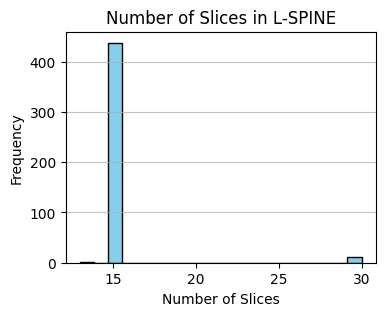

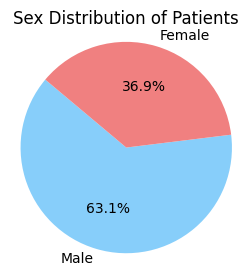

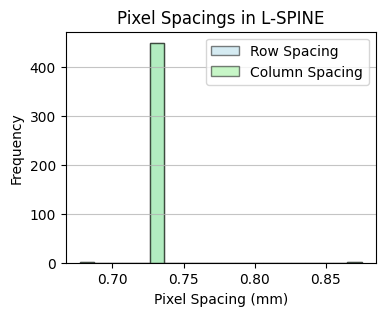

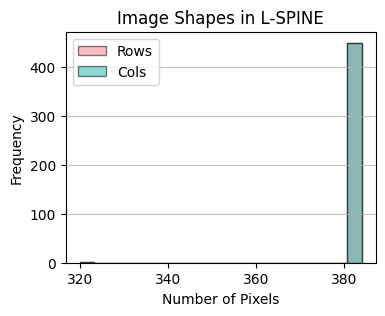

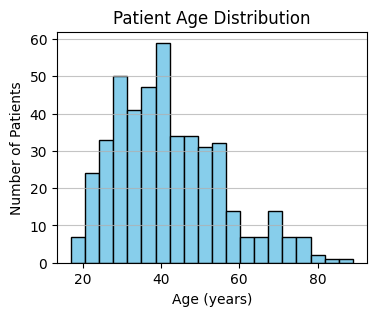

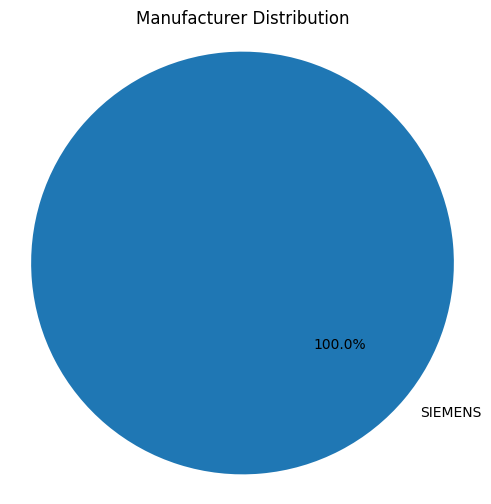

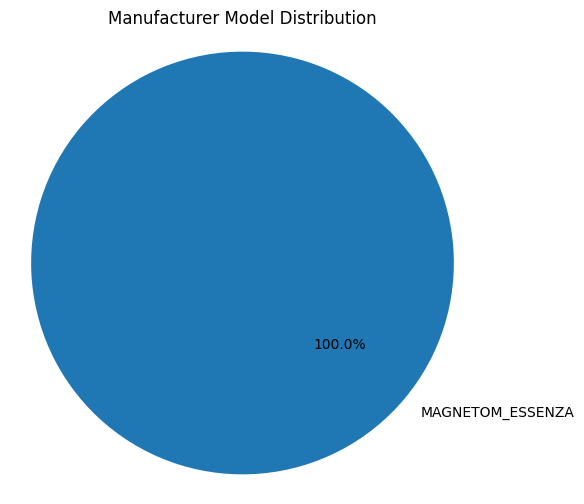

In [8]:
# ---- EDA summary ----

# Gender ratio
from collections import Counter

gender_counts = Counter(genders)
total_patients = sum(gender_counts.values())
print("\nSex distribution:")
for g, c in gender_counts.items():
    print(f"  {g}: {c} ({c/total_patients:.2%})")

# Pixel resolution statistics
# Filter out missing values (None)
valid_pixel_spacings = [ps for ps in pixel_spacings if None not in ps]
if valid_pixel_spacings:
    ps_array = np.array(valid_pixel_spacings, dtype=float)
    mean_row_spacing = ps_array[:, 0].mean()
    mean_col_spacing = ps_array[:, 1].mean()
    print("\nPixel spacing (mm):")
    print(f"  Number with valid spacing: {len(valid_pixel_spacings)}")
    print(f"  Mean row spacing: {mean_row_spacing:.4f} mm")
    print(f"  Mean col spacing: {mean_col_spacing:.4f} mm")
    print(f"  Unique spacings: {set(valid_pixel_spacings)}")
else:
    print("\nNo valid PixelSpacing found in series.")

# Image size statistics
shapes_array = np.array(image_shapes)
mean_rows = shapes_array[:, 0].mean()
mean_cols = shapes_array[:, 1].mean()
unique_shapes = {tuple(s) for s in image_shapes}
print("\nImage shape (rows x cols):")
print(f"  Mean size: {mean_rows:.1f} x {mean_cols:.1f}")
print(f"  Unique shapes: {unique_shapes}")

# Mean number of slices
num_slices_array = np.array(num_slices_list)
print("\nNumber of slices per volume:")
print(f"  Mean: {num_slices_array.mean():.1f}")
print(f"  Min : {num_slices_array.min()}")
print(f"  Max : {num_slices_array.max()}")

# histogram of number of slices
plt.figure(figsize=(4, 3))
plt.hist(num_slices_array, bins=20, color='skyblue', edgecolor='black')
plt.title(f'Number of Slices in L-SPINE')
plt.xlabel('Number of Slices')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# pie chart of gender
labels = ["Male", "Female"]
sizes = gender_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightskyblue','lightcoral',  'lightgreen'])   
plt.title('Sex Distribution of Patients')
plt.axis('equal')
plt.show()

# histogram of pixel spacings
if valid_pixel_spacings:
    plt.figure(figsize=(4, 3))
    plt.hist(ps_array[:, 0], bins=20, alpha=0.5, label='Row Spacing', color='lightblue', edgecolor='black')
    plt.hist(ps_array[:, 1], bins=20, alpha=0.5, label='Column Spacing', color='lightgreen', edgecolor='black')
    plt.title(f'Pixel Spacings in L-SPINE')
    plt.xlabel('Pixel Spacing (mm)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

# histogram of image shapes
rows = shapes_array[:, 0]
cols = shapes_array[:, 1]
plt.figure(figsize=(4, 3))
plt.hist(rows, bins=20, alpha=0.5, label='Rows', color='lightcoral', edgecolor='black')
plt.hist(cols, bins=20, alpha=0.5, label='Cols', color='lightseagreen', edgecolor='black')
plt.title(f'Image Shapes in L-SPINE')
plt.xlabel('Number of Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# age histogram
if valid_ages:
    plt.figure(figsize=(4, 3))
    plt.hist(age_array, bins=20, color='skyblue', edgecolor='black')
    plt.title('Patient Age Distribution')
    plt.xlabel('Age (years)')
    plt.ylabel('Number of Patients')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

# manufacturer distribution
manu_counts = Counter(manufacturers)
labels = list(manu_counts.keys())
sizes = manu_counts.values()
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('Manufacturer Distribution')
plt.axis('equal')
plt.show()

# manufacturer model distribution
model_counts = Counter(manufacturer_models)
labels = list(model_counts.keys())
sizes = model_counts.values()
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('Manufacturer Model Distribution')
plt.axis('equal')
plt.show()


In [ ]:
NIFTI_OUT_DIR = "Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002"
os.makedirs(NIFTI_OUT_DIR, exist_ok=True)

print("\nExporting series to NIfTI...")

for entry in all_l_spine_volumes:
    study_id = entry["study_id"]
    series_name = entry["series_name"]
    volume = entry["volume"]
    dsets = entry["datasets"]

    # Use first slice header for spacing/orientation
    ds0 = dsets[0]

    # In-plane spacing
    pixel_spacing = getattr(ds0, "PixelSpacing", [1.0, 1.0])
    row_spacing, col_spacing = float(pixel_spacing[0]), float(pixel_spacing[1])

    # Slice thickness or spacing between slices
    slice_thickness = float(getattr(ds0, "SliceThickness", 1.0))

    # Build basic affine: assumes axial orientation without rotation
    # For more accurate orientation, you’d parse ImageOrientationPatient + ImagePositionPatient.
    affine = np.diag([col_spacing, row_spacing, slice_thickness, 1.0])

    # NIfTI expects (X, Y, Z); volume is (Z, Y, X) -> transpose
    volume_zyx = volume  # (z, y, x)
    volume_xyz = np.transpose(volume_zyx, (2, 1, 0))  # (x, y, z)

    nifti_img = nib.Nifti1Image(volume_xyz, affine)

    # Build filename: STUDY_SERIES_TARGET.nii.gz
    safe_series = series_name.replace("/", "_")
    fname = f"{study_id}_{safe_series}_{TARGET_SEQUENCE}.nii.gz"
    out_path = os.path.join(NIFTI_OUT_DIR, fname)

    nib.save(nifti_img, out_path)
    print(f"  Saved NIfTI: {out_path}")

print("Done exporting all series to NIfTI.")


Exporting series to NIfTI...
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0001_L-SPINE_LSS_20160309_091629_240000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0002_L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0003_L-SPINE_LSS_20160411_134646_314000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0004_L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0005_L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0007_L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Datasets/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002/0009_L-SPINE_CLINICAL_LIBRARIES_20160712_142958_190000_T2_TSE_SAG_3

### Spider dataset

In [ ]:
SPIDER_IMG_DIR = "Data/SPIDER/images"
SPIDER_OVERVIEW_CSV = "Data/SPIDER/overview.csv"

overview_df = pd.read_csv(SPIDER_OVERVIEW_CSV)
overview_df = overview_df[overview_df["BodyPartExamined"] == "LSPINE"].copy()

print("SPIDER overview.csv shape:", overview_df.shape)
print("Columns:", list(overview_df.columns))

spider_records = []      # per image
genders = []
ages = []                # age in years (float), if available
num_vertebrae_list = []
num_discs_list = []
image_shapes = []        # (z, y, x)
pixel_spacings = []      # (sz, sy, sx) in mm, when available
manufacturers = []
manufacturer_model_names = []
device_serial_numbers = []

def get_image_path(new_file_name):
    fname = f"{new_file_name}.mha"
    return os.path.join(SPIDER_IMG_DIR, fname)

def parse_birth_date_to_age(birth_date_str):
    """
    Parse birth_date from overview.csv and return approx age in years.
    Assumes birth_date is in a parseable date format (e.g. 'YYYY-MM-DD').
    Returns None if missing or unparsable.
    """
    if pd.isna(birth_date_str) or str(birth_date_str).strip() == "":
        return None
    try:
        # Try common formats; adjust if your CSV uses a different one
        for fmt in ("%Y-%m-%d", "%d.%m.%Y", "%Y/%m/%d"):
            try:
                dob = datetime.strptime(str(birth_date_str), fmt)
                break
            except ValueError:
                dob = None
        if dob is None:
            return None
        today = datetime.today()
        age_years = (today - dob).days / 365.25
        return float(age_years)
    except Exception:
        return None

for idx, row in overview_df.iterrows():
    new_name = row["new_file_name"]          # e.g. "1_t1"
    img_path = get_image_path(new_name)

    if not os.path.isfile(img_path):
        print(f"Missing image file for {new_name}: {img_path}")
        continue

    try:
        img = sitk.ReadImage(img_path)
    except Exception as e:
        print(f"Failed to read {img_path}: {e}")
        continue

    arr = sitk.GetArrayFromImage(img)   # (z, y, x)
    spacing = img.GetSpacing()          # (sx, sy, sz)
    sx, sy, sz = spacing
    sz_arr, sy_arr, sx_arr = arr.shape

    sex = row.get("sex", "Unknown").replace(" ", "")
    num_vertebrae = row.get("num_vertebrae", np.nan)
    num_discs = row.get("num_discs", np.nan)
    birth_date = row.get("birth_date", None)
    age_years = parse_birth_date_to_age(birth_date)
    manufacturer = row.get("Manufacturer", "Unknown")
    manufacturers.append(manufacturer)
    manufacturer_model_name = row.get("ManufacturerModelName", "Unknown")
    manufacturer_model_names.append(manufacturer_model_name)
    device_serial_number = row.get("DeviceSerialNumber", "Unknown")
    device_serial_numbers.append(device_serial_number)

    genders.append(sex if pd.notna(sex) and sex != "" else "Unknown")
    num_vertebrae_list.append(num_vertebrae)
    num_discs_list.append(num_discs)
    image_shapes.append((sz_arr, sy_arr, sx_arr))
    pixel_spacings.append((sz, sy, sx))
    ages.append(age_years)

    spider_records.append({
        "new_file_name": new_name,
        "path": img_path,
        "sex": sex,
        "age_years": age_years,
        "num_vertebrae": num_vertebrae,
        "num_discs": num_discs,
        "shape_zyx": (sz_arr, sy_arr, sx_arr),
        "spacing_xyz": (sx, sy, sz),
    })

print(f"\nTotal SPIDER images read: {len(spider_records)}")

# Gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nSPIDER gender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# Age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid birth_date information available for age computation.")

# Vertebrae / discs statistics
nv_arr = np.array([v for v in num_vertebrae_list if pd.notna(v)], dtype=float)
nd_arr = np.array([d for d in num_discs_list if pd.notna(d)], dtype=float)

if nv_arr.size > 0:
    print("\nNumber of vertebrae per case:")
    print(f"  Mean: {nv_arr.mean():.2f}")
    print(f"  Min : {nv_arr.min():.0f}")
    print(f"  Max : {nv_arr.max():.0f}")
else:
    print("\nNo num_vertebrae information available.")

if nd_arr.size > 0:
    print("\nNumber of discs per case:")
    print(f"  Mean: {nd_arr.mean():.2f}")
    print(f"  Min : {nd_arr.min():.0f}")
    print(f"  Max : {nd_arr.max():.0f}")
else:
    print("\nNo num_discs information available.")

# Image shape statistics
if image_shapes:
    shapes_array = np.array(image_shapes, dtype=int)
    mean_z = shapes_array[:, 0].mean()
    mean_y = shapes_array[:, 1].mean()
    mean_x = shapes_array[:, 2].mean()
    unique_shapes = {tuple(s) for s in image_shapes}
    print("\nImage shape (z, y, x):")
    print(f"  Mean size: {mean_z:.1f} x {mean_y:.1f} x {mean_x:.1f}")
    print(f"  Unique shapes: {unique_shapes}")
else:
    print("\nNo shapes collected.")

# Pixel spacing statistics (mm)
valid_spacings = [ps for ps in pixel_spacings if all(v is not None for v in ps)]
if valid_spacings:
    ps_array = np.array(valid_spacings, dtype=float)   # (n, 3) [sz, sy, sx]
    mean_sz = ps_array[:, 0].mean()
    mean_sy = ps_array[:, 1].mean()
    mean_sx = ps_array[:, 2].mean()
    print("\nVoxel spacing (mm) (sz, sy, sx):")
    print(f"  Mean: {mean_sz:.4f} x {mean_sy:.4f} x {mean_sx:.4f}")
    print(f"  Unique spacings: {set(tuple(np.round(ps, 4)) for ps in ps_array)}")
else:
    print("\nNo valid spacing information found in SPIDER images.")


SPIDER overview.csv shape: (258, 39)
Columns: ['new_file_name', 'num_vertebrae', 'num_discs', 'sex', 'birth_date', 'subset', 'AngioFlag', 'BodyPartExamined', 'DeviceSerialNumber', 'EchoNumbers', 'EchoTime', 'EchoTrainLength', 'FlipAngle', 'ImagedNucleus', 'ImagingFrequency', 'InPlanePhaseEncodingDirection', 'MRAcquisitionType', 'MagneticFieldStrength', 'Manufacturer', 'ManufacturerModelName', 'NumberOfPhaseEncodingSteps', 'PercentPhaseFieldOfView', 'PercentSampling', 'PhotometricInterpretation', 'PixelBandwidth', 'PixelSpacing', 'RepetitionTime', 'SAR', 'SamplesPerPixel', 'ScanningSequence', 'SequenceName', 'SeriesDescription', 'SliceThickness', 'SoftwareVersions', 'SpacingBetweenSlices', 'SpecificCharacterSet', 'TransmitCoilName', 'WindowCenter', 'WindowWidth']

Total SPIDER images read: 258

SPIDER gender distribution:
  F: 167 (64.73%)
  M: 91 (35.27%)

No valid birth_date information available for age computation.

Number of vertebrae per case:
  Mean: 6.75
  Min : 6
  Max : 9

Num

In [ ]:

# histogram of manufacturer
manufacturer_counts = Counter(manufacturers)
labels = list(manufacturer_counts.keys())
sizes = list(manufacturer_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightblue', edgecolor='black')
plt.title('SPIDER Manufacturer Distribution')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# pie chart of manufacturer
labels = list(manufacturer_counts.keys())
sizes = manufacturer_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.axis('equal')
plt.show()

# histogram of manufacturer model names
model_name_counts = Counter(manufacturer_model_names)
labels = list(model_name_counts.keys())
sizes = list(model_name_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightgreen', edgecolor='black')
plt.title('SPIDER Manufacturer Model Name Distribution')
plt.xlabel('Manufacturer Model Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


# sex pie chart
labels = ["Female", "Male"]
sizes = gender_counts.values()
plt.figure(figsize=(3, 3)) 
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue', 'lightgreen'])
plt.title('SPIDER Sex Distribution')
plt.axis('equal')
plt.show()

zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]

# histogram of image size
shapes_array = np.array(image_shapes)
plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='height', color='lightcoral', edgecolor='black')
plt.title('SPIDER Image Sizes')
plt.xlabel('Number of Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# histogram of image size
shapes_array = np.array(image_shapes)
zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='height', color='lightcoral', edgecolor='black')
plt.hist(ys, bins=20, alpha=0.5, label='width', color='lightseagreen', edgecolor='black')
plt.title('SPIDER Image Sizes')
plt.xlabel('Number of Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# histogram of image size
shapes_array = np.array(image_shapes)
zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(xs, bins=20, alpha=0.5     , label='slices', color='lightskyblue', edgecolor='black')
plt.xlabel('Number of slices')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

### Lumbar vertebral body and intervertebral disc segmentation in multi-scanner and multi-modal MRI

In [ ]:
OSF_META_CSV = "Data/osf-metadata/metadata_extracted.csv"
OSF_IMG_ROOT = "Data/osf-files"

osf_df = pd.read_csv(OSF_META_CSV)

print("OSF metadata shape:", osf_df.shape)
print("Columns:", list(osf_df.columns))

ID_COL = "ID"

osf_records = []

genders = []
ages = []            # years
manufacturers = []
manufacturer_models = []
image_shapes = []    # (x, y, z)
voxel_spacings = []  # (sx, sy, sz)

def find_nifti_images_for_id(subject_id):
    """
    For a given ID (e.g. '02'), search:
      Datasets/osf-files/ID02/*/Images/*T2*.nii.gz
    and return full paths.
    """
    id_dir = f"ID{str(subject_id).zfill(2)}"
    root = os.path.join(OSF_IMG_ROOT, id_dir)
    if not os.path.isdir(root):
        return []

    found = []
    for manu_model in os.listdir(root):
        manu_model_path = os.path.join(root, manu_model)
        images_dir = os.path.join(manu_model_path, "Images")
        if not os.path.isdir(images_dir):
            continue
        for fname in os.listdir(images_dir):
            if fname.lower().find("t2") != -1 and fname.lower().endswith((".nii", ".nii.gz")):
                found.append(os.path.join(images_dir, fname))
    return found

def parse_age_from_meta(row):
    """
    Use 'Age' column from metadata (already in years).
    """
    if "Age" in row and pd.notna(row["Age"]):
        try:
            return float(row["Age"])
        except Exception:
            return None
    return None

def safe_load_nifti(path):
    """
    Try nibabel first, fall back to SimpleITK if nibabel fails.
    Returns (data_array, spacing_xyz, shape_xyz).
    """
    # Try nibabel
    try:
        img = nib.load(path)
        data = img.get_fdata()
        shape = data.shape
        spatial_shape = shape[:3] if len(shape) >= 3 else shape
        zooms = img.header.get_zooms()
        if len(zooms) >= 3:
            sx, sy, sz = zooms[:3]
        else:
            sx = sy = sz = None
        return data, (sx, sy, sz), spatial_shape
    except Exception:
        pass

    # Fallback: SimpleITK
    try:
        sitk_img = sitk.ReadImage(path)
        arr_zyx = sitk.GetArrayFromImage(sitk_img)
        sz, sy, sx = sitk_img.GetSpacing()
        # Convert to (x, y, z) order for shape
        spatial_shape = (arr_zyx.shape[2], arr_zyx.shape[1], arr_zyx.shape[0])
        # Reorder spacing to match (x, y, z)
        spacing_xyz = (sx, sy, sz)
        # For consistency with nibabel path, return data in (x,y,z) orientation
        data_xyz = np.transpose(arr_zyx, (2, 1, 0))
        return data_xyz, spacing_xyz, spatial_shape
    except Exception as e:
        raise e

invalid_nifti_paths = []

for idx, row in osf_df.iterrows():
    subject_id = row[ID_COL]
    img_paths = find_nifti_images_for_id(subject_id)
    if not img_paths:
        continue

    for img_path in img_paths:
        try:
            data, (sx, sy, sz), spatial_shape = safe_load_nifti(img_path)
        except Exception as e:
            print(f"Failed to read NIfTI {img_path}: {e}")
            invalid_nifti_paths.append((img_path, str(e)))
            continue

        # spatial_shape is already (x, y, z)
        # sx, sy, sz are voxel spacings

        parts = os.path.normpath(img_path).split(os.sep)
        manu = "Unknown"
        manu_model = "Unknown"
        for i, p in enumerate(parts):
            if p.startswith("ID") and i + 1 < len(parts):
                manu_model_full = parts[i + 1]   # e.g. Philips_Achieva
                if "_" in manu_model_full:
                    manu, model = manu_model_full.split("_", 1)
                else:
                    manu, model = manu_model_full, ""
                manu_model = model if model else manu_model_full
                break

        sex = row.get("Gender", "Unknown")
        if pd.isna(sex) or str(sex).strip() == "":
            sex = "Unknown"
        age_years = parse_age_from_meta(row)

        genders.append(sex)
        ages.append(age_years)
        manufacturers.append(manu)
        manufacturer_models.append(manu_model)
        image_shapes.append(spatial_shape)
        voxel_spacings.append((sx, sy, sz))

        osf_records.append({
            "id": subject_id,
            "path": img_path,
            "sex": sex,
            "age_years": age_years,
            "manufacturer": manu,
            "manufacturer_model": manu_model,
            "shape_xyz": spatial_shape,
            "spacing_xyz": (sx, sy, sz),
        })

print(f"\nTotal OSF images read (nibabel or SimpleITK): {len(osf_records)}")
print(f"Total invalid / non-readable T2 files skipped: {len(invalid_nifti_paths)}")

# Gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nOSF gender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# Age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid age information available in OSF metadata.")

# Manufacturer / model stats
manu_counts = Counter(manufacturers)
model_counts = Counter(manufacturer_models)

print("\nManufacturer distribution (from directory names):")
for m, c in manu_counts.items():
    frac = c / len(manufacturers) if manufacturers else 0
    print(f"  {m}: {c} ({frac:.2%})")

print("\nManufacturerModelName distribution (parsed from directory names):")
for m, c in model_counts.items():
    frac = c / len(manufacturer_models) if manufacturer_models else 0
    print(f"  {m}: {c} ({frac:.2%})")

# shape statistics
if image_shapes:
    shapes_array = np.array(image_shapes, dtype=float)
    mean_x = shapes_array[:, 0].mean()
    mean_y = shapes_array[:, 1].mean()
    mean_z = shapes_array[:, 2].mean()
    unique_shapes = {tuple(s) for s in image_shapes}
    print("\nImage shape (x, y, z):")
    print(f"  Mean size: {mean_x:.1f} x {mean_y:.1f} x {mean_z:.1f}")
    print(f"  Unique shapes: {unique_shapes}")
else:
    print("\nNo shapes collected for OSF dataset.")

# spacing statistics
valid_spacings = [ps for ps in voxel_spacings if all(v is not None for v in ps)]
if valid_spacings:
    ps_array = np.array(valid_spacings, dtype=float)   # (n, 3) [sx, sy, sz]
    mean_sx = ps_array[:, 0].mean()
    mean_sy = ps_array[:, 1].mean()
    mean_sz = ps_array[:, 2].mean()
    print("\nVoxel spacing (mm) (sx, sy, sz):")
    print(f"  Mean: {mean_sx:.4f} x {mean_sy:.4f} x {mean_sz:.4f}")
    print(f"  Unique spacings: {set(tuple(np.round(ps, 4)) for ps in ps_array)}")
else:
    print("\nNo valid spacing information found in OSF images.")

OSF metadata shape: (34, 5)
Columns: ['ID', 'Gender', 'Age', 'Clinical Indication', 'Clinical Indication Code']

Total OSF images read (nibabel or SimpleITK): 51
Total invalid / non-readable T2 files skipped: 0

OSF gender distribution:
  Female: 30 (58.82%)
  Male: 21 (41.18%)

Age (years):
  Count with age: 51
  Mean: 63.2
  Std : 15.2
  Min : 30.0
  Max : 88.1

Manufacturer distribution (from directory names):
  Philips: 36 (70.59%)
  Siemens: 14 (27.45%)
  GE: 1 (1.96%)

ManufacturerModelName distribution (parsed from directory names):
  Achieva: 27 (52.94%)
  Verio: 4 (7.84%)
  Avanto: 5 (9.80%)
  Ingenia: 4 (7.84%)
  Symphony: 1 (1.96%)
  Amira: 1 (1.96%)
  Elition: 4 (7.84%)
  Espree: 1 (1.96%)
  Aera: 1 (1.96%)
  Magnetom: 1 (1.96%)
  Achieva_external: 1 (1.96%)
  Signa: 1 (1.96%)

Image shape (x, y, z):
  Mean size: 676.1 x 675.1 x 16.8
  Unique shapes: {(704, 704, 15), (704, 704, 21), (512, 512, 14), (448, 448, 18), (1200, 1200, 17), (896, 896, 15), (1120, 1120, 19), (384, 38

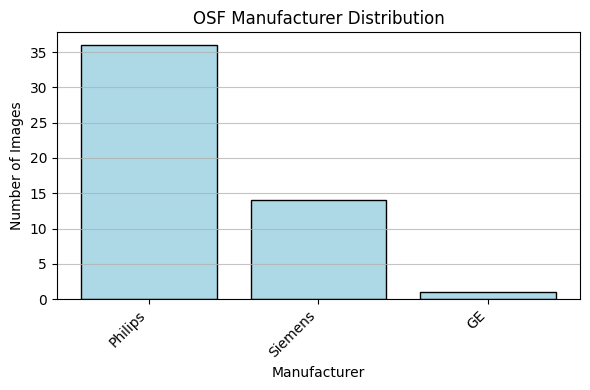

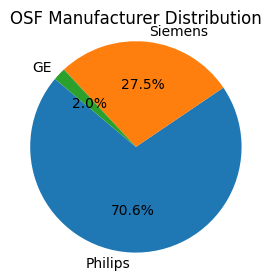

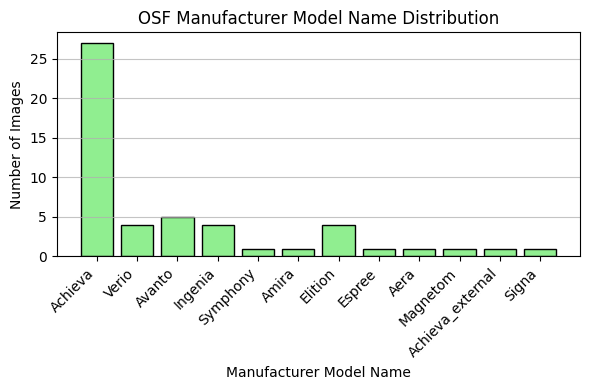

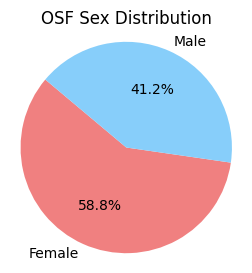

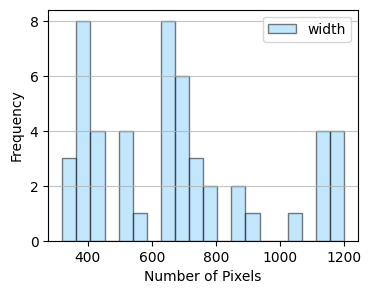

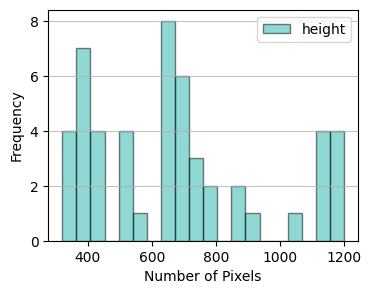

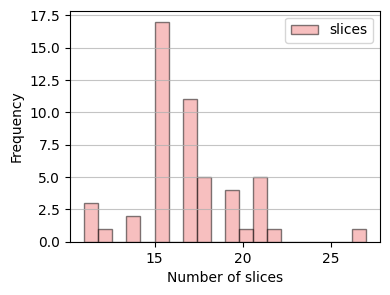

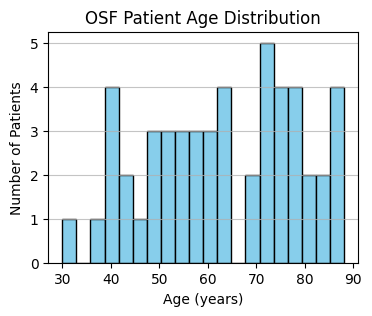

In [12]:
# histogram of manufacturer
manufacturer_counts = Counter(manufacturers)
labels = list(manufacturer_counts.keys())
sizes = list(manufacturer_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightblue', edgecolor='black')
plt.title('OSF Manufacturer Distribution')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show() 

# pie chart of manufacturer
labels = list(manufacturer_counts.keys())
sizes = manufacturer_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('OSF Manufacturer Distribution')
plt.axis('equal')
plt.show()

# histogram of manufacturer model names
model_name_counts = Counter(manufacturer_models)
labels = list(model_name_counts.keys())
sizes = list(model_name_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightgreen', edgecolor='black')
plt.title('OSF Manufacturer Model Name Distribution')       
plt.xlabel('Manufacturer Model Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()  

# sex pie chart
labels = ["Female", "Male"]
labels = gender_counts.keys()
sizes = gender_counts.values()
plt.figure(figsize=(3, 3)) 
plt.pie(sizes, labels=labels, autopct='%1.1f%%',       startangle=140, colors=['lightcoral', 'lightskyblue', 'lightgreen']) 
plt.title('OSF Sex Distribution')
plt.axis('equal')
plt.show()

# histogram of image size
shapes_array = np.array(image_shapes)
xs = shapes_array[:, 0]
ys = shapes_array[:, 1]
zs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(xs, bins=20, alpha=0.5, label='width', color='lightskyblue', edgecolor='black')
plt.xlabel('Number of Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

plt.figure(figsize=(4, 3))
plt.hist(ys, bins=20, alpha=0.5, label='height', color='lightseagreen', edgecolor='black')
plt.xlabel('Number of Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='slices', color='lightcoral', edgecolor='black')
plt.xlabel('Number of slices')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

# age histogram
if valid_ages:
    plt.figure(figsize=(4, 3))
    plt.hist(age_array, bins=20, color='skyblue', edgecolor='black')
    plt.title('OSF Patient Age Distribution')
    plt.xlabel('Age (years)')
    plt.ylabel('Number of Patients')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

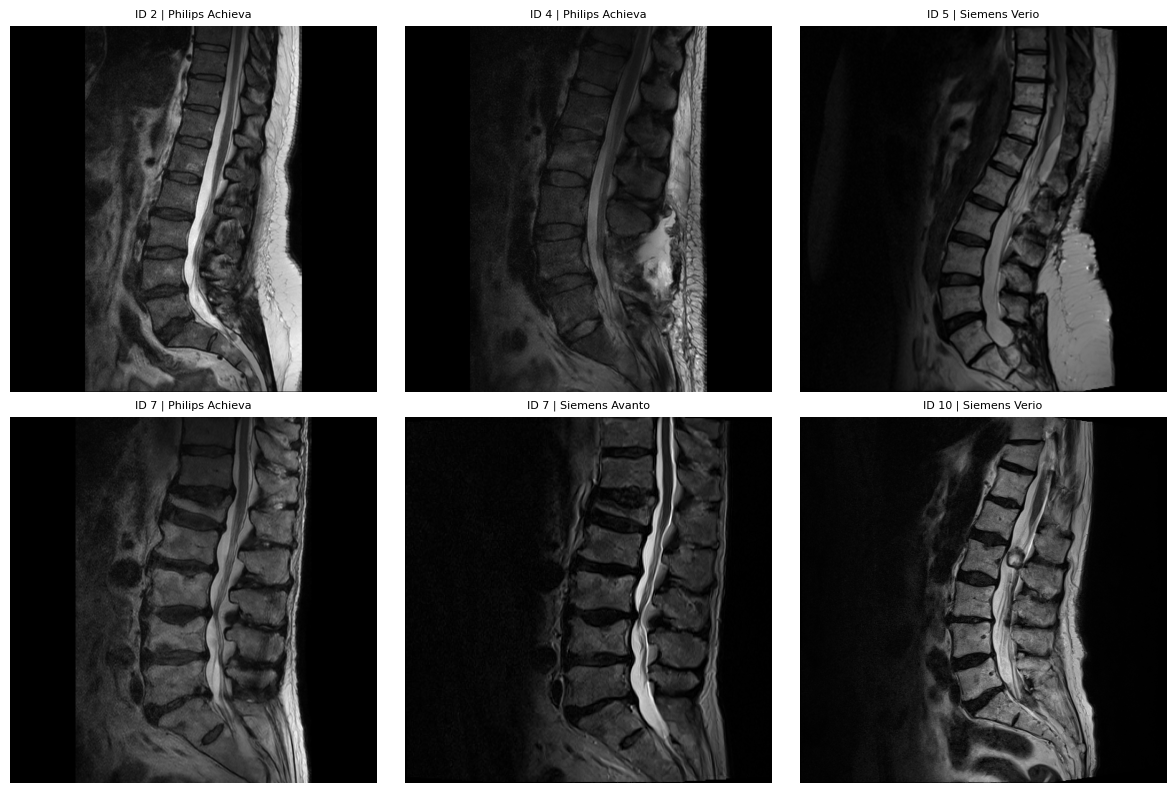

In [13]:
def show_middle_slices_osf(records, max_cases=6, figsize=(12, 8)):
    """
    Visualize the middle axial slice for up to `max_cases` OSF images.
    """
    n = min(len(records), max_cases)
    if n == 0:
        print("No OSF records available for visualization.")
        return

    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, rec in zip(axes, records[:n]):
        data, _, spatial_shape = safe_load_nifti(rec["path"])
        # data is (x, y, z); pick middle slice along z
        x, y, z = spatial_shape
        mid = z // 2
        slice_xy = data[:, :, mid]

        ax.imshow(slice_xy.T, cmap="gray", origin="lower")
        title = f"ID {rec['id']} | {rec['manufacturer']} {rec['manufacturer_model']}"
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example: visualize first 6 volumes
show_middle_slices_osf(osf_records, max_cases=6)